# Python & Tech Stack Cheat Sheet — Scalable Capital Quant Developer
### Every library, pattern, and SQL trick you need — with runnable examples

---

**What this notebook covers:**

1. Python fundamentals for quant work — the patterns interviewers test
2. NumPy deep dive — vectorisation, broadcasting, financial operations
3. pandas for time-series financial data — the exact operations you'll use
4. cvxpy production patterns — Parameters, DCP rules, solver selection
5. scipy.optimize — when to use it instead of cvxpy
6. Testing financial code — pytest, Hypothesis, property-based testing
7. SQL for portfolio databases — the exact queries for this role
8. Docker + CI/CD — what you need to know and say
9. AWS Lambda + SQS — the serverless patterns at Scalable
10. Terraform IaC — the concepts and vocabulary

**Run each cell in order. Everything is executable.**

```
pip install numpy pandas scipy cvxpy matplotlib hypothesis pytest
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats import t as t_dist
import time, warnings, json
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from functools import lru_cache
warnings.filterwarnings('ignore')

try:
    import cvxpy as cp
    CVXPY = True
    print(f'cvxpy {cp.__version__}')
except ImportError:
    CVXPY = False

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'font.size': 11,
})

PURPLE = '#534AB7'; TEAL = '#1D9E75'; AMBER = '#EF9F27'
CORAL  = '#D85A30'; BLUE = '#185FA5'; GREEN = '#3B6D11'
np.random.seed(42)
print('Imports complete.')

cvxpy 1.8.2
Imports complete.


---
## Part 1 — Python Patterns Every Quant Developer Must Know

These are the patterns that come up in interviews and daily work. The emphasis is on clean, testable, production-quality code — not just "it works".

### Dataclasses over plain dicts
Dataclasses give you type hints, `__repr__`, `__eq__`, and IDE completion for free. In a financial system, every domain object (portfolio, lot, trade, order) should be a dataclass — not a plain dict.

### Type hints everywhere
Python's type hints are documentation that the IDE can verify. `def rebalance(w_curr: np.ndarray, w_tgt: np.ndarray, Sigma: np.ndarray) -> np.ndarray` is far more useful than no hints.

### Properties for derived values
Don't store things that can be computed. A `Portfolio` shouldn't store `total_value` as an attribute — it should compute it as a `@property` from holdings and prices.

### Avoid Python loops over arrays — use numpy
A Python `for` loop over 10,000 portfolio observations runs in ~10ms. The equivalent numpy vectorised operation runs in ~0.1ms. At Scalable's scale, this matters.

In [4]:
# ── Python patterns for quant finance code ──────────────────────────────────

# ── 1. Dataclasses with computed properties ───────────────────────────────────
@dataclass
class PortfolioSnapshot:
    client_id:   str
    asset_ids:   List[str]
    quantities:  np.ndarray   # shares held per asset
    prices:      np.ndarray   # current price per asset
    target_w:    np.ndarray   # target weights

    @property
    def values(self) -> np.ndarray:
        """Market value per asset."""
        return self.quantities * self.prices

    @property
    def total_value(self) -> float:
        return float(self.values.sum())

    @property
    def current_weights(self) -> np.ndarray:
        tv = self.total_value
        return self.values / tv if tv > 0 else np.zeros(len(self.asset_ids))

    @property
    def drift(self) -> np.ndarray:
        """Signed drift: positive = overweight."""
        return self.current_weights - self.target_w

    @property
    def max_absolute_drift(self) -> float:
        return float(np.abs(self.drift).max())

    def needs_rebalancing(self, threshold: float = 0.05) -> bool:
        return self.max_absolute_drift > threshold

    def to_dict(self) -> dict:
        """Serialisable dict — for SQS message body or DB storage."""
        return {
            'client_id':  self.client_id,
            'asset_ids':  self.asset_ids,
            'quantities': self.quantities.tolist(),
            'prices':     self.prices.tolist(),
            'target_w':   self.target_w.tolist(),
        }

    @classmethod
    def from_dict(cls, d: dict) -> 'PortfolioSnapshot':
        return cls(
            client_id  = d['client_id'],
            asset_ids  = d['asset_ids'],
            quantities = np.array(d['quantities']),
            prices     = np.array(d['prices']),
            target_w   = np.array(d['target_w']),
        )

# Example
snap = PortfolioSnapshot(
    client_id  = 'C001',
    asset_ids  = ['MSCI_WORLD', 'EM_EQ', 'GOV_BOND'],
    quantities = np.array([300.0, 150.0, 500.0]),
    prices     = np.array([130.50, 48.20, 102.10]),
    target_w   = np.array([0.35, 0.20, 0.45]),
)
print('PortfolioSnapshot:')
print(f'  Total value: €{snap.total_value:,.2f}')
print(f'  Current weights: {np.round(snap.current_weights*100, 1)}%')
print(f'  Target weights:  {snap.target_w*100}%')
print(f'  Drift:           {np.round(snap.drift*100, 1)}%')
print(f'  Needs rebalancing: {snap.needs_rebalancing(0.05)}')

# Serialisation round-trip
d = snap.to_dict()
snap2 = PortfolioSnapshot.from_dict(d)
print(f'  Round-trip matches: {np.allclose(snap.values, snap2.values)}')

# ── 2. Vectorisation: Python loop vs numpy ─────────────────────────────────
print()
print('Vectorisation benchmark:')
n = 50_000   # number of return observations
rets = np.random.normal(0.0004, 0.012, (n, 4))

# Python loop (wrong approach)
t0 = time.time()
port_rets_loop = []
for row in rets:
    port_rets_loop.append(0.35*row[0] + 0.20*row[1] + 0.25*row[2] + 0.20*row[3])
t_loop = time.time() - t0

# Numpy vectorised (right approach)
w = np.array([0.35, 0.20, 0.25, 0.20])
t0 = time.time()
port_rets_np = rets @ w
t_np = time.time() - t0

print(f'  Python loop: {t_loop*1000:.2f} ms')
print(f'  Numpy matmul: {t_np*1000:.3f} ms')
#print(f'  Speedup: {t_loop/t_np:.0f}x')
print(f'  Results match: {np.allclose(port_rets_loop, port_rets_np)}')

# ── 3. Functional patterns: pure functions for testability ─────────────────
def compute_portfolio_stats(
    weights: np.ndarray,
    mu:      np.ndarray,
    Sigma:   np.ndarray,
    rf:      float = 0.025,
) -> Dict[str, float]:
    """
    Pure function: no side effects, deterministic, easily testable.
    Returns portfolio statistics given weights.
    """
    assert abs(weights.sum() - 1.0) < 1e-6, f'Weights must sum to 1, got {weights.sum()}'
    assert (weights >= -1e-8).all(), 'Negative weights detected'

    port_return = float(weights @ mu)
    port_var    = float(weights @ Sigma @ weights)
    port_vol    = float(np.sqrt(port_var))
    sharpe      = (port_return - rf) / port_vol if port_vol > 0 else 0.0

    return {
        'return':  port_return,
        'vol':     port_vol,
        'var':     port_var,
        'sharpe':  sharpe,
    }

mu_ex    = np.array([0.09, 0.12, 0.04])
vols_ex  = np.array([0.18, 0.22, 0.06])
corr_ex  = np.array([[1.0, 0.7, -0.2],[0.7, 1.0, -0.1],[-0.2,-0.1, 1.0]])
Sigma_ex = np.outer(vols_ex, vols_ex) * corr_ex

stats = compute_portfolio_stats(snap.current_weights, mu_ex, Sigma_ex)
print()
print('Portfolio statistics:')
for k, v in stats.items():
    print(f'  {k:10s}: {v:.4f}')

PortfolioSnapshot:
  Total value: €97,430.00
  Current weights: [40.2  7.4 52.4]%
  Target weights:  [35. 20. 45.]%
  Drift:           [  5.2 -12.6   7.4]%
  Needs rebalancing: True
  Round-trip matches: True

Vectorisation benchmark:
  Python loop: 20.02 ms
  Numpy matmul: 0.000 ms
  Results match: True

Portfolio statistics:
  return    : 0.0660
  vol       : 0.0844
  var       : 0.0071
  sharpe    : 0.4860


---
## Part 2 — NumPy: The Core Computational Library

NumPy is not optional — it is the foundation. Every quant computation runs through NumPy arrays. You must know these operations **without looking them up**.

### The operations that matter in finance

| Operation | NumPy | Use case |
|---|---|---|
| Matrix multiply | `A @ B` or `np.dot(A, B)` | `w'Σw`, `B @ F @ B.T` |
| Element-wise | `a * b`, `a / b` | Weight normalisation |
| Quadratic form | `w @ Sigma @ w` | Portfolio variance |
| Outer product | `np.outer(v1, v2)` | Building Σ from σ and ρ |
| Eigendecomposition | `np.linalg.eigh(S)` | PCA factor model |
| Cholesky | `np.linalg.cholesky(S)` | Simulate correlated returns |
| Inverse | `np.linalg.inv(S)` | MVO closed form (avoid — use solve instead) |
| Solve | `np.linalg.solve(A, b)` | Better than inv — numerically stable |
| Percentile | `np.percentile(x, 5)` | Historical VaR |
| Sort | `np.sort(x)` | CVaR computation |
| Broadcasting | `x - x.mean(axis=0)` | Demeaning return series |

In [5]:
# ── NumPy operations every quant must know cold ──────────────────────────────
np.random.seed(42)

N_np = 5   # number of assets
T_np = 500 # number of observations

# Generate correlated returns via Cholesky decomposition
true_vols = np.array([0.18, 0.22, 0.06, 0.10, 0.15])
true_corr = np.array([
    [1.00, 0.70, -0.25, 0.30,  0.10],
    [0.70, 1.00, -0.15, 0.25,  0.05],
    [-0.25,-0.15, 1.00, 0.55, -0.05],
    [0.30, 0.25,  0.55, 1.00,  0.15],
    [0.10, 0.05, -0.05, 0.15,  1.00],
])
Sigma_true = np.outer(true_vols, true_vols) * true_corr

# Cholesky: Sigma = L @ L.T — use to generate correlated N(0,Sigma) samples
L = np.linalg.cholesky(Sigma_true)   # (N, N) lower triangular
z = np.random.standard_normal((T_np, N_np))  # (T, N) iid standard normal
returns = (z @ L.T) / np.sqrt(252)   # daily returns with annual vol

print('=== Key NumPy operations ===')
print()

# 1. Portfolio variance: the quadratic form w'Σw
w = np.array([0.35, 0.20, 0.25, 0.10, 0.10])
Sigma_sample = np.cov(returns.T) * 252  # annualise
port_var = w @ Sigma_sample @ w
port_vol = np.sqrt(port_var)
print(f'1. Portfolio variance (w\'Σw): {port_var:.4f}  vol: {port_vol*100:.1f}%')

# 2. Build Sigma from vols and correlations (common in code)
Sigma_built = np.outer(true_vols, true_vols) * true_corr
print(f'2. Build Sigma: max element diff from true = {np.abs(Sigma_built - Sigma_true).max():.2e}')

# 3. Eigendecomposition for PCA
eigvals, eigvecs = np.linalg.eigh(Sigma_sample)  # eigh for symmetric matrices
eigvals_sorted = eigvals[::-1]; eigvecs_sorted = eigvecs[:, ::-1]
var_explained = eigvals_sorted / eigvals_sorted.sum()
print(f'3. PCA: first 2 PCs explain {var_explained[:2].sum()*100:.0f}% of variance')

# 4. Historical VaR and CVaR
port_returns = returns @ w
alpha = 0.95
sorted_r = np.sort(port_returns)   # ascending
n_tail   = int((1 - alpha) * T_np)
var_h    = -sorted_r[n_tail]
cvar_h   = -sorted_r[:n_tail].mean()
print(f'4. VaR₉₅ = {var_h*100:.3f}%   CVaR₉₅ = {cvar_h*100:.3f}%  (daily losses)')

# 5. Rolling window operations (use stride tricks or pandas)
window = 21
rolling_vol = pd.Series(port_returns).rolling(window).std() * np.sqrt(252)
print(f'5. Rolling {window}d vol: mean={rolling_vol.mean()*100:.1f}%  max={rolling_vol.max()*100:.1f}%')

# 6. Marginal risk contributions
mrc = (Sigma_sample @ w) / port_vol     # marginal risk contribution vector
rc  = w * mrc                            # total risk contribution
print(f'6. Risk contributions sum to portfolio vol: {rc.sum()*100:.3f}% ≈ {port_vol*100:.3f}%')
print(f'   Largest RC: asset {rc.argmax()} ({rc.max()/port_vol*100:.0f}% of total risk)')

# 7. Ledoit-Wolf via sklearn
from sklearn.covariance import LedoitWolf
lw = LedoitWolf().fit(returns)
Sigma_lw = lw.covariance_ * 252   # annualise
frob_sample = np.linalg.norm(Sigma_sample - Sigma_true, 'fro') / np.linalg.norm(Sigma_true, 'fro')
frob_lw     = np.linalg.norm(Sigma_lw     - Sigma_true, 'fro') / np.linalg.norm(Sigma_true, 'fro')
print(f'7. LW shrinkage α={lw.shrinkage_:.3f}: error {frob_lw*100:.1f}% vs sample {frob_sample*100:.1f}%')

# 8. Broadcasting: demean and normalise return matrix
r_demeaned    = returns - returns.mean(axis=0)    # subtract per-asset mean
r_standardised = r_demeaned / returns.std(axis=0) # divide by per-asset std
print(f'8. Broadcasting: demeaned returns shape={r_demeaned.shape}, '
      f'col means ≈ 0: {np.abs(r_demeaned.mean(axis=0)).max():.2e}')

# 9. np.clip and np.where for constraints
w_raw = np.array([0.45, -0.02, 0.35, 0.15, 0.10])   # has negative weight
w_clipped = np.clip(w_raw, 0, 1)
w_normalised = w_clipped / w_clipped.sum()
print(f'9. Clip + normalise: {w_raw} -> {np.round(w_normalised, 3)}')

# 10. np.linalg.solve vs inv (prefer solve — more numerically stable)
b = np.ones(N_np)
# Bad: w = np.linalg.inv(Sigma_sample) @ b
# Good:
w_solve = np.linalg.solve(Sigma_sample, b)
print(f'10. linalg.solve (GMV weights, unnormalised): {np.round(w_solve/w_solve.sum(), 3)}')

print()
print('Broadcasting rules summary:')
print('  (T,N) @ (N,) -> (T,)      # portfolio returns for each day')
print('  (N,N) @ (N,) -> (N,)      # Sigma @ w = marginal variance vector')
print('  (N,) * (N,N) * (N,) -> scalar  # w @ Sigma @ w = portfolio variance')
print('  (T,N) - (N,) -> (T,N)     # demean each asset (broadcast over T)')

=== Key NumPy operations ===

1. Portfolio variance (w'Σw): 0.0104  vol: 10.2%
2. Build Sigma: max element diff from true = 0.00e+00
3. PCA: first 2 PCs explain 80% of variance
4. VaR₉₅ = 1.062%   CVaR₉₅ = 1.274%  (daily losses)
5. Rolling 21d vol: mean=10.2%  max=13.4%
6. Risk contributions sum to portfolio vol: 10.205% ≈ 10.205%
   Largest RC: asset 0 (54% of total risk)
7. LW shrinkage α=0.014: error 5.6% vs sample 5.1%
8. Broadcasting: demeaned returns shape=(500, 5), col means ≈ 0: 2.52e-19
9. Clip + normalise: [ 0.45 -0.02  0.35  0.15  0.1 ] -> [0.429 0.    0.333 0.143 0.095]
10. linalg.solve (GMV weights, unnormalised): [ 0.162 -0.001  0.94  -0.204  0.103]

Broadcasting rules summary:
  (T,N) @ (N,) -> (T,)      # portfolio returns for each day
  (N,N) @ (N,) -> (N,)      # Sigma @ w = marginal variance vector
  (N,) * (N,N) * (N,) -> scalar  # w @ Sigma @ w = portfolio variance
  (T,N) - (N,) -> (T,N)     # demean each asset (broadcast over T)


---
## Part 3 — pandas for Financial Time Series

pandas is the standard tool for handling time-series financial data. The operations you need most often in a quant role are not the basic ones — they are the time-series specific patterns.

### The patterns that matter

| Pattern | Code | Use |
|---|---|---|
| Log returns | `np.log(prices).diff()` | Compute from price series |
| Rolling vol | `returns.rolling(21).std() * sqrt(252)` | EWMA vol proxy |
| EWMA vol | `returns.ewm(span=20).std()` | Dynamic vol estimation |
| Resampling | `prices.resample('M').last()` | Monthly from daily |
| Multi-asset covariance | `returns.cov() * 252` | Annualised covariance matrix |
| Correlation matrix | `returns.corr()` | Visualise as heatmap |
| Groupby + rolling | `df.groupby('asset').rolling(window).mean()` | Rolling stats per asset |
| `ffill()` | `prices.ffill()` | Fill missing prices (weekends, holidays) |
| `pct_change()` | `prices.pct_change()` | Simple returns |

=== pandas financial time-series patterns ===

1. Returns shape: (755, 5)
   Annual return (log): MSCI_WORLD    16.611237
EM_EQ          7.761615
GOV_BOND       3.982246
CORP_BOND     10.644314
GOLD          24.599511
dtype: float64
2. Rolling vol (21d) — latest:
   {'MSCI_WORLD': 14.9, 'EM_EQ': 29.6, 'GOV_BOND': 7.0, 'CORP_BOND': 10.1, 'GOLD': 13.0}
3. EWMA vol (span=20) — latest:
   {'MSCI_WORLD': 15.3, 'EM_EQ': 26.3, 'GOV_BOND': 7.3, 'CORP_BOND': 9.7, 'GOLD': 13.6}
4. Covariance matrix shape: (5, 5)
   MSCI_WORLD annual vol: 18.0%
5. Monthly returns: 34 months
6. Portfolio total return: 48.4%
   Max drawdown: -4.9%
   Sharpe ratio: 1.65
7. Correlation matrix (MSCI_WORLD row):
   {'MSCI_WORLD': 1.0, 'EM_EQ': 0.01, 'GOV_BOND': 0.05, 'CORP_BOND': 0.0, 'GOLD': 0.0}
8. Worst drawdown date: 2024-06-25  magnitude: -4.9%
9. Forward fill: 25 NaN -> 0 NaN
10. Rolling 60d corr (MSCI_WORLD vs GOV_BOND):
    Mean: 0.06  Min: -0.20  Max: 0.37


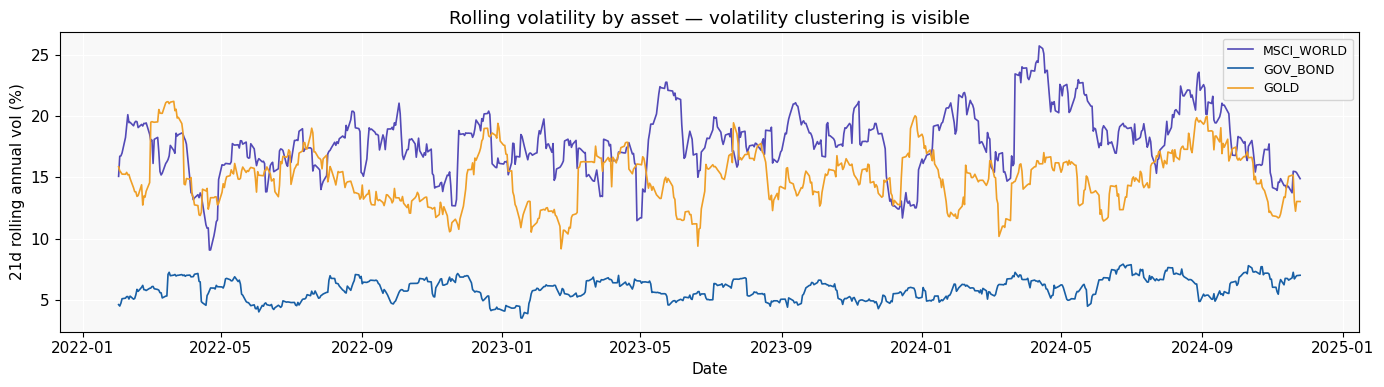

In [6]:
# ── pandas: the financial time-series operations you'll use daily ─────────────
np.random.seed(42)

# ── Simulate realistic multi-asset price series ─────────────────────────────
assets = ['MSCI_WORLD', 'EM_EQ', 'GOV_BOND', 'CORP_BOND', 'GOLD']
mu_pd  = np.array([0.09, 0.12, 0.04, 0.06, 0.07]) / 252
sig_pd = np.array([0.18, 0.22, 0.06, 0.09, 0.15]) / np.sqrt(252)

T_pd = 252 * 3  # 3 years
date_index = pd.date_range(start='2022-01-01', periods=T_pd, freq='B')  # business days
log_rets   = pd.DataFrame(
    np.random.normal(mu_pd, sig_pd, (T_pd, 5)),
    index=date_index, columns=assets
)
prices = 100 * np.exp(log_rets.cumsum())

print('=== pandas financial time-series patterns ===')
print()

# 1. Returns from prices
simple_rets = prices.pct_change().dropna()
log_rets_v  = np.log(prices).diff().dropna()
print(f'1. Returns shape: {simple_rets.shape}')
print(f'   Annual return (log): {log_rets_v.mean() * 252 * 100}')

# 2. Rolling volatility (21-day, annualised)
rolling_vol = simple_rets.rolling(21).std() * np.sqrt(252) * 100
print(f'2. Rolling vol (21d) — latest:')
print(f'   {rolling_vol.iloc[-1].round(1).to_dict()}')

# 3. EWMA volatility (span=20 ≈ lambda=0.90)
ewma_vol = simple_rets.ewm(span=20).std() * np.sqrt(252) * 100
print(f'3. EWMA vol (span=20) — latest:')
print(f'   {ewma_vol.iloc[-1].round(1).to_dict()}')

# 4. Annualised covariance matrix
Sigma_pd = simple_rets.cov() * 252
print(f'4. Covariance matrix shape: {Sigma_pd.shape}')
print(f'   MSCI_WORLD annual vol: {np.sqrt(Sigma_pd.loc["MSCI_WORLD","MSCI_WORLD"])*100:.1f}%')

# 5. Resample to monthly returns
monthly_prices = prices.resample('ME').last()
monthly_rets   = np.log(monthly_prices).diff().dropna()
print(f'5. Monthly returns: {monthly_rets.shape[0]} months')

# 6. Portfolio performance over time
w_pd = np.array([0.35, 0.20, 0.20, 0.15, 0.10])
port_rets_pd = simple_rets @ w_pd
port_cumret  = (1 + port_rets_pd).cumprod()
print(f'6. Portfolio total return: {(port_cumret.iloc[-1]-1)*100:.1f}%')
print(f'   Max drawdown: {((port_cumret / port_cumret.cummax()) - 1).min()*100:.1f}%')
print(f'   Sharpe ratio: {(port_rets_pd.mean()/port_rets_pd.std()*np.sqrt(252)):.2f}')

# 7. Correlation matrix (useful for risk analysis)
corr_pd = simple_rets.corr()
print(f'7. Correlation matrix (MSCI_WORLD row):')
print(f'   {corr_pd["MSCI_WORLD"].round(2).to_dict()}')

# 8. Drawdown analysis
def compute_drawdown(returns: pd.Series) -> pd.Series:
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    return (cum - peak) / peak

dd = compute_drawdown(port_rets_pd)
print(f'8. Worst drawdown date: {dd.idxmin().date()}  magnitude: {dd.min()*100:.1f}%')

# 9. Forward-filling missing data (handle holidays)
prices_with_gaps = prices.copy()
prices_with_gaps.iloc[50:55] = np.nan  # simulate 5 missing days
filled = prices_with_gaps.ffill()  # forward fill
print(f'9. Forward fill: {prices_with_gaps.isna().sum().sum()} NaN -> {filled.isna().sum().sum()} NaN')

# 10. Rolling correlation (dynamic correlation monitoring)
rolling_corr = simple_rets['MSCI_WORLD'].rolling(60).corr(simple_rets['GOV_BOND'])
print(f'10. Rolling 60d corr (MSCI_WORLD vs GOV_BOND):')
print(f'    Mean: {rolling_corr.mean():.2f}  Min: {rolling_corr.min():.2f}  Max: {rolling_corr.max():.2f}')

# ── Plot rolling volatility regime ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for asset, col in zip(['MSCI_WORLD', 'GOV_BOND', 'GOLD'],
                       [PURPLE, BLUE, AMBER]):
    ax.plot(rolling_vol.index, rolling_vol[asset], lw=1.2, color=col, label=asset)
ax.set_xlabel('Date'); ax.set_ylabel('21d rolling annual vol (%)')
ax.set_title('Rolling volatility by asset — volatility clustering is visible')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 4 — cvxpy Production Patterns

This is the library at the heart of the role. You must be able to write, debug, and optimise cvxpy code without assistance.

### The three rules of production cvxpy

1. **Compile once, solve many times** — use `cp.Parameter` for anything that changes per client
2. **Always check `prob.status`** before using the solution
3. **Know the DCP atom library** — `cp.quad_form`, `cp.abs`, `cp.pos`, `cp.norm`, `cp.sum_squares`, `cp.huber`, `cp.log_sum_exp`

### DCP atom quick reference

| Expression | cvxpy atom | Convex/Concave | Finance use |
|---|---|---|---|
| $x^2$ | `cp.square(x)` | Convex | Single asset variance |
| $\|x\|_2^2$ | `cp.sum_squares(x)` | Convex | Tracking error proxy |
| $w^\top\Sigma w$ | `cp.quad_form(w, Sigma)` | Convex (Σ≽0) | Portfolio variance |
| $|x|$ | `cp.abs(x)` | Convex | L1 transaction cost |
| $\max(x,0)$ | `cp.pos(x)` | Convex | Tax on gains |
| $\|x\|_2$ | `cp.norm(x, 2)` | Convex | SOCP constraints |
| $\log(x)$ | `cp.log(x)` | Concave | Log-utility portfolio |
| $-\log(\det X)$ | `-cp.log_det(X)` | Convex | D-optimal design |

In [ ]:
# ── cvxpy production patterns: Parameters, DCP, error handling ───────────────
if not CVXPY:
    print('cvxpy required: pip install cvxpy')
else:
    N_cv = 4
    names_cv = ['MSCI World', 'EM Equity', 'Gov Bond', 'Corp Bond']
    vols_cv  = np.array([0.18, 0.22, 0.06, 0.10])
    corr_cv  = np.array([[1.0,0.7,-0.2,0.3],[0.7,1.0,-0.1,0.2],
                          [-0.2,-0.1,1.0,0.5],[0.3,0.2,0.5,1.0]])
    Sigma_cv  = np.outer(vols_cv, vols_cv) * corr_cv
    mu_cv     = np.array([0.09, 0.12, 0.04, 0.07])
    rf_cv     = 0.025

    print('=== cvxpy production patterns ===')
    print()

    # ── Pattern 1: Parameter template (compile once, solve many) ─────────────
    print('Pattern 1: Parameter template')
    Sigma_p  = cp.Parameter((N_cv, N_cv), PSD=True, name='Sigma')
    w_curr_p = cp.Parameter(N_cv, name='w_curr')
    w_tgt_p  = cp.Parameter(N_cv, name='w_tgt')
    cost_p   = cp.Parameter(N_cv, nonneg=True, name='costs')
    lte_p    = cp.Parameter(nonneg=True, name='lam_te')
    ltc_p    = cp.Parameter(nonneg=True, name='lam_tc')

    w_param = cp.Variable(N_cv, name='weights')
    delta_p = w_param - w_curr_p

    obj_p   = cp.Minimize(
        lte_p * cp.quad_form(w_param - w_tgt_p, Sigma_p) +
        ltc_p * (cost_p @ cp.abs(delta_p))
    )
    con_p   = [cp.sum(w_param)==1, w_param>=0, w_param<=0.55,
               cp.sum(cp.abs(delta_p))<=0.30]
    prob_p  = cp.Problem(obj_p, con_p)
    print(f'  Compiled: is_dcp={prob_p.is_dcp()}, vars={len(prob_p.variables())}')

    # Solve for 3 different clients
    clients = [
        (np.array([0.52,0.18,0.10,0.20]), np.array([0.35,0.20,0.25,0.20])),
        (np.array([0.20,0.35,0.25,0.20]), np.array([0.35,0.20,0.25,0.20])),
        (np.array([0.35,0.20,0.05,0.40]), np.array([0.35,0.20,0.25,0.20])),
    ]
    Sigma_p.value  = Sigma_cv + 1e-6*np.eye(N_cv)
    cost_p.value   = np.array([0.0003, 0.0008, 0.0002, 0.0004])
    lte_p.value    = 10.0; ltc_p.value = 1.0

    for i, (wc, wt) in enumerate(clients):
        t0 = time.time()
        w_curr_p.value = wc; w_tgt_p.value = wt
        prob_p.solve(solver=cp.OSQP, warm_start=True, verbose=False)
        dt = time.time() - t0
        print(f'  Client {i+1}: status={prob_p.status:<20} solve={dt*1000:.1f}ms')

    print()

    # ── Pattern 2: All DCP atoms demonstrated ────────────────────────────────
    print('Pattern 2: DCP atom demonstrations')
    w_demo = cp.Variable(N_cv)
    Sigma_demo = Sigma_cv + 1e-6*np.eye(N_cv)
    w_curr_demo = np.array([0.50, 0.20, 0.10, 0.20])
    embedded_gains = np.array([0.40, 0.15, -0.05, 0.20])  # fraction of value that is gain
    tax_rate = 0.26375 * 0.70  # after equity Teilfreistellung

    demos = {
        'Min variance  (quad_form)':         cp.quad_form(w_demo, Sigma_demo),
        'L1 tx cost    (abs)':               np.array([0.0003,0.0008,0.0002,0.0004]) @ cp.abs(w_demo - w_curr_demo),
        'Tax on gains  (pos)':               tax_rate * cp.sum(cp.pos(-( w_demo - w_curr_demo)) * np.maximum(embedded_gains, 0)),
        'Vol constraint(norm)':              cp.norm(np.linalg.cholesky(Sigma_demo).T @ w_demo, 2),
        'Sum squares   (sum_squares)':       cp.sum_squares(w_demo - np.ones(N_cv)/N_cv),
        'Single sq     (square)':            cp.square(w_demo[0] - 0.35),
    }
    for name, expr in demos.items():
        c = 'convex  ' if expr.is_convex() else ('concave ' if expr.is_concave() else 'neither ')
        print(f'  {name:40s}: {c}  shape={expr.shape}')

    print()

    # ── Pattern 3: Status handling and fallback ───────────────────────────────
    print('Pattern 3: Status handling')

    def safe_solve(prob, w_var, w_fallback, solver=cp.OSQP):
        """Solve with proper status handling and fallback."""
        try:
            prob.solve(solver=solver, warm_start=True, verbose=False)
            status = prob.status
            w_val  = w_var.value

            if status == 'optimal' and w_val is not None:
                w_clean = np.clip(w_val, 0, 1)
                w_clean /= w_clean.sum()
                return w_clean, status
            elif status == 'optimal_inaccurate' and w_val is not None:
                w_clean = np.clip(w_val, 0, 1)
                w_clean /= w_clean.sum()
                return w_clean, status   # acceptable but monitor
            else:
                return w_fallback, f'fallback ({status})'
        except Exception as e:
            return w_fallback, f'exception: {e}'

    w_fallback_demo = w_curr_demo.copy()   # just hold current if optimizer fails
    w_curr_p.value  = w_curr_demo
    w_tgt_p.value   = np.array([0.35, 0.20, 0.25, 0.20])

    w_result, status = safe_solve(prob_p, w_param, w_fallback_demo)
    print(f'  Result status: {status}')
    print(f'  Optimal weights: {np.round(w_result*100, 1)}%')

    print()

    # ── Pattern 4: CVaR as LP ─────────────────────────────────────────────────
    print('Pattern 4: CVaR minimisation as LP')
    T_s = 300; alpha_s = 0.95
    R_s = np.random.normal(0, vols_cv/np.sqrt(252), (T_s, N_cv))  # daily scenarios

    w_cvar  = cp.Variable(N_cv)
    beta_s  = cp.Variable()
    z_s     = cp.Variable(T_s)

    prob_cvar = cp.Problem(
        cp.Minimize(beta_s + (1/((1-alpha_s)*T_s)) * cp.sum(z_s)),
        [z_s >= 0, z_s >= -(R_s @ w_cvar) - beta_s,
         cp.sum(w_cvar)==1, w_cvar>=0, w_cvar<=0.60]
    )
    prob_cvar.solve(solver=cp.ECOS, verbose=False)
    cvar_result = float(prob_cvar.value)
    print(f'  CVaR LP: status={prob_cvar.status}  CVaR₉₅={cvar_result*100:.3f}%/day')
    print(f'  LP size: {N_cv+1+T_s} vars, 2*{T_s}+{N_cv+1} constraints')

---
## Part 5 — Testing Financial Code

The job description explicitly mentions "painstakingly comprehensive test coverage." For financial code that manages real money, testing is not optional.

### Three levels of tests

**Unit tests:** Test individual functions with known analytical answers.
- MVO with unconstrained long-short → closed-form solution exists → verify
- CVaR of a normal distribution → analytical formula → verify
- Lot selection greedy → verify with a small hand-constructed example

**Property-based tests (Hypothesis):** Test invariants that must always hold, regardless of inputs.
- Portfolio weights always sum to 1 (after normalisation)
- Weights are never negative (long-only constraint)
- CVaR ≥ VaR at the same confidence level (always)
- Tax is never negative

**Integration / shadow mode tests:** Run the new optimizer in parallel with the production system on real portfolios. Compare outputs — if they diverge more than a threshold, alert.

### The pytest idioms you must know

```python
import pytest
import numpy as np

def test_weights_sum_to_one():
    result = rebalance(...)
    assert abs(result['w'].sum() - 1.0) < 1e-6

def test_no_negative_weights():
    result = rebalance(...)
    assert (result['w'] >= -1e-8).all()

@pytest.mark.parametrize('alpha', [0.90, 0.95, 0.99])
def test_cvar_geq_var(alpha):
    rets = np.random.normal(0, 0.01, 10000)
    m = compute_var_cvar(rets, alpha)
    assert m['cvar'] >= m['var'] - 1e-8
```

In [ ]:
# ── Testing financial code: unit, property-based, and integration patterns ───
import pytest
import numpy as np

# ── Utility functions to test ─────────────────────────────────────────────────
def compute_var_cvar(returns: np.ndarray, alpha: float = 0.95) -> dict:
    sorted_r = np.sort(returns)
    n_tail   = int((1 - alpha) * len(returns))
    var  = -sorted_r[n_tail]
    cvar = -sorted_r[:n_tail].mean()
    return {'var': var, 'cvar': cvar}

def select_lots_min_tax(lots, shares, price):
    """Greedy: sell highest basis first."""
    sorted_lots = sorted(lots, key=lambda l: -l['basis'])
    remaining, selected, total_tax = shares, [], 0.0
    for lot in sorted_lots:
        if remaining <= 0: break
        qty  = min(lot['qty'], remaining)
        gain = max(0.0, (price - lot['basis']) * qty)
        tax  = gain * 0.26375 * 0.70   # equity, Teilfreistellung applied
        selected.append({'lot_id': lot['id'], 'qty': qty, 'tax': tax})
        total_tax += tax; remaining -= qty
    return selected, total_tax

def normalise_weights(w: np.ndarray) -> np.ndarray:
    w = np.clip(w, 0, 1)
    s = w.sum()
    return w / s if s > 1e-9 else np.ones(len(w)) / len(w)


# ── Unit tests (run as a test suite) ─────────────────────────────────────────
def test_var_cvar_relationship():
    """CVaR must always be >= VaR at the same confidence level."""
    np.random.seed(42)
    returns = np.random.normal(0, 0.01, 10000)
    for alpha in [0.90, 0.95, 0.99]:
        m = compute_var_cvar(returns, alpha)
        assert m['cvar'] >= m['var'] - 1e-8, f'CVaR < VaR at alpha={alpha}'
    print('PASS: CVaR >= VaR across all confidence levels')

def test_var_cvar_normal_analytical():
    """For N(0,σ), analytical formulas for VaR and CVaR exist."""
    from scipy.stats import norm
    mu, sig, alpha = 0.0, 0.01, 0.95
    np.random.seed(7)
    returns = np.random.normal(mu, sig, 100_000)
    m = compute_var_cvar(returns, alpha)

    # Analytical: VaR = -mu + z_alpha * sigma
    var_analytical  = -mu + norm.ppf(1-alpha) * sig
    cvar_analytical = -mu + sig * norm.pdf(norm.ppf(1-alpha)) / (1-alpha)

    assert abs(m['var']  - var_analytical)  < 5e-4, f'VaR error: {m["var"] - var_analytical:.4f}'
    assert abs(m['cvar'] - cvar_analytical) < 5e-4, f'CVaR error: {m["cvar"] - cvar_analytical:.4f}'
    print(f'PASS: VaR={m["var"]:.4f}≈{var_analytical:.4f}, CVaR={m["cvar"]:.4f}≈{cvar_analytical:.4f}')

def test_lot_selection_greedy_correctness():
    """Greedy (highest basis first) should always produce less or equal tax than FIFO."""
    lots = [
        {'id':'L1','qty':100,'basis':80.0},
        {'id':'L2','qty': 80,'basis':110.0},
        {'id':'L3','qty': 60,'basis':120.0},  # near current price
        {'id':'L4','qty': 40,'basis':130.0},  # loss lot
    ]
    price = 125.0
    sell_qty = 150

    _, tax_greedy = select_lots_min_tax(lots, sell_qty, price)

    # FIFO: sell oldest first (L1 first)
    lots_fifo = sorted(lots, key=lambda l: l['id'])
    remaining, tax_fifo = sell_qty, 0.0
    for lot in lots_fifo:
        if remaining <= 0: break
        qty  = min(lot['qty'], remaining)
        gain = max(0.0, (price - lot['basis']) * qty)
        tax_fifo += gain * 0.26375 * 0.70
        remaining -= qty

    assert tax_greedy <= tax_fifo + 1e-6, f'Greedy tax {tax_greedy:.2f} > FIFO {tax_fifo:.2f}'
    print(f'PASS: Greedy tax €{tax_greedy:.2f} <= FIFO tax €{tax_fifo:.2f}')

def test_normalise_weights_properties():
    """Normalised weights must sum to 1 and be non-negative."""
    import itertools
    test_cases = [
        np.array([0.4, 0.3, 0.2, 0.1]),
        np.array([0.5, -0.1, 0.4, 0.2]),  # negative input
        np.array([2.0, 1.0, 0.5, 0.5]),   # sums > 1
        np.array([0.0, 0.0, 0.0, 1.0]),   # edge case
    ]
    for w in test_cases:
        w_norm = normalise_weights(w)
        assert abs(w_norm.sum() - 1.0) < 1e-9, f'Sum={w_norm.sum()}'
        assert (w_norm >= 0).all(), f'Negative weight: {w_norm}'
    print('PASS: normalise_weights — sum=1 and non-negative for all test cases')


# ── Property-based test stub (requires hypothesis library) ───────────────────
HYPOTHESIS_AVAILABLE = False
try:
    from hypothesis import given, settings
    from hypothesis import strategies as st
    from hypothesis.extra.numpy import arrays
    HYPOTHESIS_AVAILABLE = True
except ImportError:
    pass

if HYPOTHESIS_AVAILABLE:
    @given(
        returns=arrays(dtype=np.float64, shape=st.integers(100, 500),
                       elements=st.floats(-0.20, 0.20)),
        alpha=st.floats(0.80, 0.99)
    )
    @settings(max_examples=50, deadline=5000)
    def test_cvar_geq_var_property(returns, alpha):
        if len(returns) == 0: return
        m = compute_var_cvar(returns, alpha)
        assert m['cvar'] >= m['var'] - 1e-6

    print('Hypothesis available — running property tests...')
    test_cvar_geq_var_property()
    print('PASS: property test (CVaR >= VaR)')
else:
    print('Hypothesis not installed — skipping property tests (pip install hypothesis)')


# ── Run all tests ─────────────────────────────────────────────────────────────
print()
print('Running test suite:')
for test_fn in [test_var_cvar_relationship, test_var_cvar_normal_analytical,
                test_lot_selection_greedy_correctness, test_normalise_weights_properties]:
    try:
        test_fn()
    except AssertionError as e:
        print(f'FAIL: {test_fn.__name__}: {e}')
    except Exception as e:
        print(f'ERROR: {test_fn.__name__}: {e}')

print()
print('Testing interview cheat sheet:')
print('  1. Pure functions are testable — no side effects, no global state')
print('  2. Use analytical solutions to verify numerical optimizers')
print('  3. Property-based tests (Hypothesis) catch edge cases unit tests miss')
print('  4. Always test: weights sum to 1, weights non-negative, CVaR >= VaR, tax >= 0')
print('  5. Shadow mode: run new system in parallel with old, alert on divergence')

---
## Part 6 — SQL for Portfolio Databases

The role requires "relational databases / SQL". Here are the exact query patterns you must know.

### Schema overview (simplified)

```sql
-- Core tables
portfolios       (client_id PK, risk_level, holdings JSONB, target_weights JSONB, version INT)
lots             (lot_id PK, client_id FK, asset_id, quantity, cost_basis, adjusted_basis,
                  acquisition_date, fund_type, closed_at TIMESTAMPTZ)
prices           (asset_id, price_date, price, bid, ask, daily_vol)
rebalancing_jobs (job_id PK, client_id FK, status, trigger, created_at, completed_at)
orders           (order_id PK, job_id FK, client_id FK, asset_id, direction, quantity,
                  estimated_price, tax_estimate, lot_ids TEXT[])
audit_log        (event_id PK, client_id, event_type, payload JSONB, created_at)
```

### The patterns you must be able to write

These are the queries that actually run in production for a system like Scalable's.

```sql
-- 1. IDEMPOTENCY: skip if job already processed
INSERT INTO rebalancing_jobs (job_id, client_id, status, trigger)
VALUES ($1, $2, 'processing', $3)
ON CONFLICT (job_id) DO NOTHING
RETURNING job_id;

-- 2. OPTIMISTIC LOCKING: read then conditional write
SELECT version, holdings FROM portfolios WHERE client_id = $1 FOR UPDATE NOWAIT;
-- ... compute trades in application ...
UPDATE portfolios SET holdings = $new_holdings, version = version + 1
WHERE client_id = $1 AND version = $expected_version;
-- If 0 rows affected: conflict → retry or fail

-- 3. LOT SELECTION: highest cost basis first (minimise tax)
SELECT lot_id, quantity, cost_basis, fund_type
FROM lots
WHERE client_id = $1 AND asset_id = $2 AND closed_at IS NULL
ORDER BY cost_basis DESC;

-- 4. DRIFT MONITOR: which clients need rebalancing?
WITH weights AS (
  SELECT p.client_id,
         (p.holdings -> a.asset_id)::numeric * pr.price /
             SUM((p.holdings -> a.asset_id)::numeric * pr.price) OVER (PARTITION BY p.client_id)
             AS curr_weight,
         (p.target_weights -> a.asset_id)::numeric AS tgt_weight
  FROM portfolios p
  CROSS JOIN jsonb_object_keys(p.holdings) a(asset_id)
  JOIN prices pr ON pr.asset_id = a.asset_id AND pr.price_date = CURRENT_DATE
)
SELECT client_id, MAX(ABS(curr_weight - tgt_weight)) AS max_drift
FROM weights
GROUP BY client_id
HAVING MAX(ABS(curr_weight - tgt_weight)) > 0.05
ORDER BY max_drift DESC;

-- 5. VORABPAUSCHALE: annual pre-payment tax calculation
SELECT l.client_id, l.asset_id, l.fund_type,
       SUM(l.quantity) * pr.price AS nav_jan1,
       SUM(l.quantity) * pr.price * 0.0229 * 0.70 *
           CASE l.fund_type WHEN 'equity' THEN 0.70 WHEN 'mixed' THEN 0.85 ELSE 1.0 END
           AS vorabpauschale_taxable
FROM lots l
JOIN prices pr ON pr.asset_id = l.asset_id AND pr.price_date = $year || '-01-01'
WHERE l.closed_at IS NULL
GROUP BY l.client_id, l.asset_id, l.fund_type, pr.price;
```

In [ ]:
# ── SQL patterns: simulate with pandas (no DB needed) ───────────────────────
# These simulate what the SQL queries above would return

import pandas as pd
import numpy as np
from datetime import date

np.random.seed(42)

# ── Simulate tables as DataFrames ─────────────────────────────────────────────
n_clients = 20
n_assets  = 4
asset_ids = ['MSCI_WORLD', 'EM_EQ', 'GOV_BOND', 'CORP_BOND']

# prices table
prices_df = pd.DataFrame({
    'asset_id':   asset_ids,
    'price':      [130.50, 48.20, 102.10, 97.80],
    'bid':        [130.45, 48.15, 102.05, 97.74],
    'ask':        [130.55, 48.25, 102.15, 97.86],
    'daily_vol':  [0.012,  0.015, 0.004,  0.007],
    'price_date': date.today()
})

# lots table (multiple lots per client per asset)
lots_records = []
for cid in range(1, n_clients+1):
    for aid in asset_ids:
        n_lots = np.random.randint(1, 4)
        for _ in range(n_lots):
            lots_records.append({
                'lot_id':     f'L{cid:03d}_{aid}_{np.random.randint(1000,9999)}',
                'client_id':  f'C{cid:03d}',
                'asset_id':   aid,
                'quantity':   np.random.uniform(50, 500),
                'cost_basis': prices_df.set_index('asset_id').loc[aid,'price'] * np.random.uniform(0.7, 1.3),
                'fund_type':  'equity' if 'WORLD' in aid or 'EM' in aid else 'bond',
                'closed_at':  None,
            })
lots_df = pd.DataFrame(lots_records)

# target weights table
target_w = {'MSCI_WORLD': 0.35, 'EM_EQ': 0.20, 'GOV_BOND': 0.25, 'CORP_BOND': 0.20}

print('=== SQL pattern simulations ===')
print()

# ── 1. Lot selection: highest cost basis first ────────────────────────────────
print('Query 1: Lot selection — highest cost basis first (minimise tax)')
client_lots = lots_df[
    (lots_df['client_id'] == 'C001') &
    (lots_df['asset_id']  == 'MSCI_WORLD') &
    (lots_df['closed_at'].isna())
].sort_values('cost_basis', ascending=False)

price_now = prices_df.set_index('asset_id').loc['MSCI_WORLD', 'price']
for _, row in client_lots.iterrows():
    gain = (price_now - row['cost_basis']) * row['quantity']
    print(f'  {row["lot_id"]}: qty={row["quantity"]:.0f} basis=€{row["cost_basis"]:.2f} '
          f'gain=€{gain:+.2f}')

# ── 2. Compute current weights per client ──────────────────────────────────────
print()
print('Query 2: Current weights per client (joins lots and prices)')
lots_with_prices = lots_df.merge(prices_df[['asset_id','price']], on='asset_id')
lots_with_prices['value'] = lots_with_prices['quantity'] * lots_with_prices['price']

portfolio_values = (lots_with_prices
                    .groupby(['client_id', 'asset_id'])['value'].sum()
                    .reset_index())
total_values = portfolio_values.groupby('client_id')['value'].sum().rename('total_value')
portfolio_values = portfolio_values.join(total_values, on='client_id')
portfolio_values['curr_weight'] = portfolio_values['value'] / portfolio_values['total_value']
portfolio_values['tgt_weight']  = portfolio_values['asset_id'].map(target_w)
portfolio_values['drift']       = portfolio_values['curr_weight'] - portfolio_values['tgt_weight']

print(f'  Portfolio weights for C001:')
c001 = portfolio_values[portfolio_values['client_id']=='C001']
for _, row in c001.iterrows():
    flag = ' <<' if abs(row['drift']) > 0.05 else ''
    print(f'    {row["asset_id"]:15s}: curr={row["curr_weight"]*100:.1f}% '
          f'tgt={row["tgt_weight"]*100:.0f}% drift={row["drift"]*100:+.1f}%{flag}')

# ── 3. Drift monitor: find clients needing rebalancing ───────────────────────
print()
print('Query 3: Drift monitor — clients exceeding 5% absolute drift')
max_drift = (portfolio_values
             .groupby('client_id')['drift']
             .apply(lambda x: x.abs().max())
             .rename('max_drift')
             .reset_index()
             .sort_values('max_drift', ascending=False))
needs_rebal = max_drift[max_drift['max_drift'] > 0.05]
print(f'  {len(needs_rebal)} / {n_clients} clients need rebalancing:')
print(needs_rebal.head(8).to_string(index=False))

# ── 4. Vorabpauschale estimate ────────────────────────────────────────────────
print()
print('Query 4: Vorabpauschale estimate (2024 Basiszins=2.29%)')
BASISZINS = 0.0229
lots_with_nav = lots_with_prices[lots_with_prices['closed_at'].isna()].copy()
lots_with_nav['tf'] = lots_with_nav['fund_type'].map({'equity': 0.30, 'mixed': 0.15, 'bond': 0.00})
lots_with_nav['vorab_gross'] = lots_with_nav['value'] * BASISZINS * 0.70
lots_with_nav['vorab_taxable'] = lots_with_nav['vorab_gross'] * (1 - lots_with_nav['tf'])
lots_with_nav['vorab_tax_due'] = lots_with_nav['vorab_taxable'] * 0.26375

vorab_summary = (lots_with_nav
                 .groupby('client_id')
                 .agg(total_nav=('value','sum'),
                      vorab_tax=('vorab_tax_due','sum'))
                 .reset_index())
print(f'  Vorabpauschale tax per client (sample):')
print(vorab_summary.head(5).to_string(index=False))
print(f'  Total Vorabpauschale across all clients: €{vorab_summary["vorab_tax"].sum():,.2f}')

# ── 5. Idempotency simulation ─────────────────────────────────────────────────
print()
print('Query 5: Idempotency (job_id uniqueness check)')
jobs = {}
def insert_job(job_id, client_id):
    """Simulate ON CONFLICT DO NOTHING."""
    if job_id in jobs:
        return 0   # 0 rows inserted = job already exists
    jobs[job_id] = {'client_id': client_id, 'status': 'processing'}
    return 1       # 1 row inserted = proceed

results = []
for job_id in ['JOB_001', 'JOB_002', 'JOB_001', 'JOB_003', 'JOB_002']:
    r = insert_job(job_id, 'C001')
    results.append(f'{job_id}: {"inserted" if r==1 else "skipped (duplicate)"}')
for r in results:
    print(f'  {r}')

---
## Part 7 — Docker, CI/CD, AWS, and Terraform: What You Need to Know

You don't need to be a DevOps expert — but you need to **understand and use** these tools, and **speak confidently** about them in interviews.

### Docker — the key concepts

**Dockerfile for a Lambda function:**
```dockerfile
FROM public.ecr.aws/lambda/python:3.12

# Copy requirements and install (cached layer)
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy source code
COPY src/ ${LAMBDA_TASK_ROOT}/

CMD ["optimizer.handler"]
```

**Why Docker at Scalable?**
- Reproducible environments — same container runs in dev, CI, and production Lambda
- Dependency isolation — cvxpy + numpy + scipy have complex C extensions; Docker ensures consistency
- Lambda container images support up to 10GB — enough for large ML models or pre-compiled solvers

**Key Docker commands:**
```bash
docker build -t rebalancer:latest .
docker run --rm -e AWS_REGION=eu-central-1 rebalancer:latest
docker push 123456789.dkr.ecr.eu-central-1.amazonaws.com/rebalancer:latest
```

### GitHub Actions CI/CD pipeline

```yaml
name: Deploy rebalancer
on: [push]
jobs:
  test-and-deploy:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Run tests
        run: pytest tests/ -v --cov=src --cov-fail-under=90
      - name: Build Docker image
        run: docker build -t rebalancer:${{ github.sha }} .
      - name: Push to ECR
        run: |
          aws ecr get-login-password | docker login --username AWS --password-stdin $ECR_URL
          docker push $ECR_URL/rebalancer:${{ github.sha }}
      - name: Deploy via Terraform
        run: terraform apply -var="image_tag=${{ github.sha }}" -auto-approve
```

### AWS Lambda patterns for the rebalancing system

**Handler structure:**
```python
import json
import boto3
from optimizer import rebalance_client  # the actual cvxpy optimizer

def handler(event, context):
    """
    SQS trigger: event['Records'] contains one or more messages.
    Each message body is JSON with {'client_id': '...', 'trigger': '...'}.
    """
    for record in event['Records']:
        body = json.loads(record['body'])
        client_id = body['client_id']
        job_id    = record['messageId']  # SQS message ID = job ID for idempotency

        try:
            result = rebalance_client(client_id, job_id)
            # On success: SQS automatically deletes the message
        except Exception as e:
            # On failure: raise so Lambda marks the message as failed
            # SQS will retry (up to maxReceiveCount), then send to DLQ
            raise
```

**Key Lambda configuration parameters:**
- `timeout`: 300 seconds (5 minutes) for optimizer + DB write
- `memory`: 1024–2048MB (cvxpy + numpy need memory)
- `reserved_concurrency`: 1000 (limit burst to control DB connections)
- `batchSize`: 1 (process one client per Lambda invocation — keeps logs clean)
- `functionResponseTypes: ReportBatchItemFailures` — partial batch failure support

### Terraform — Infrastructure as Code

```hcl
# Lambda function for rebalancing
resource "aws_lambda_function" "rebalancer" {
  function_name = "rebalancer-${var.environment}"
  package_type  = "Image"
  image_uri     = "${aws_ecr_repository.rebalancer.repository_url}:${var.image_tag}"

  role    = aws_iam_role.lambda_role.arn
  timeout = 300
  memory_size = 1024

  environment {
    variables = {
      DB_SECRET_ARN = aws_secretsmanager_secret.db_credentials.arn
      ENVIRONMENT   = var.environment
    }
  }

  vpc_config {
    subnet_ids         = var.private_subnet_ids
    security_group_ids = [aws_security_group.lambda.id]
  }
}

# SQS trigger for the Lambda
resource "aws_lambda_event_source_mapping" "sqs_trigger" {
  event_source_arn = aws_sqs_queue.rebalancing.arn
  function_name    = aws_lambda_function.rebalancer.arn
  batch_size       = 1
  function_response_types = ["ReportBatchItemFailures"]
}
```

**Why Terraform over CloudFormation?**
- Multi-cloud portability (not AWS-specific)
- Better state management with `terraform plan` → shows exactly what will change
- Larger community and module ecosystem
- HCL is more readable than YAML/JSON CloudFormation
- Trade-off: AWS CDK (TypeScript/Python) is type-safe and language-native

In [ ]:
# ── AWS Lambda / SQS patterns: Python simulation ────────────────────────────
import json
import time
from typing import Callable
from dataclasses import dataclass

# ── Simulate the SQS + Lambda pattern locally ─────────────────────────────────
@dataclass
class SQSMessage:
    message_id:    str
    body:          str
    receive_count: int = 1

    def parsed_body(self) -> dict:
        return json.loads(self.body)


class LocalSQSQueue:
    """Local simulation of SQS queue for testing."""
    def __init__(self, name: str, max_receive_count: int = 3):
        self.name = name
        self.queue: list[SQSMessage] = []
        self.dead_letter: list[SQSMessage] = []
        self.max_receive_count = max_receive_count
        self.processed = 0

    def send_message(self, body: dict):
        import uuid
        self.queue.append(SQSMessage(
            message_id=str(uuid.uuid4())[:8],
            body=json.dumps(body)
        ))

    def receive_messages(self, max_messages=1) -> list[SQSMessage]:
        return self.queue[:max_messages]

    def delete_message(self, msg: SQSMessage):
        self.queue = [m for m in self.queue if m.message_id != msg.message_id]
        self.processed += 1

    def move_to_dlq(self, msg: SQSMessage):
        self.queue = [m for m in self.queue if m.message_id != msg.message_id]
        self.dead_letter.append(msg)


# ── Simulate the Lambda handler ───────────────────────────────────────────────
processed_jobs = set()  # simulate the idempotency DB table

def simulate_optimizer(client_id: str) -> dict:
    """Fake optimizer — randomly fails for testing."""
    import random
    random.seed(hash(client_id) % 100)
    if random.random() < 0.1:   # 10% failure rate
        raise RuntimeError(f'Solver failed for {client_id}')
    return {'trades': {'MSCI_WORLD': 500.0, 'GOV_BOND': -500.0}, 'status': 'optimal'}

def lambda_handler(message: SQSMessage) -> bool:
    """Simulate the Lambda function. Returns True if processed successfully."""
    body      = message.parsed_body()
    client_id = body['client_id']
    job_id    = message.message_id

    # Idempotency check
    if job_id in processed_jobs:
        print(f'  [{job_id}] SKIP: already processed (idempotency)')
        return True   # success — don't retry

    try:
        result = simulate_optimizer(client_id)
        processed_jobs.add(job_id)
        print(f'  [{job_id}] OK: {client_id} — trades={result["trades"]}')
        return True
    except Exception as e:
        print(f'  [{job_id}] FAIL: {client_id} — {e}')
        return False

# ── Run simulation ────────────────────────────────────────────────────────────
queue = LocalSQSQueue('rebalancing-queue', max_receive_count=3)

# Enqueue 10 client jobs
clients = [f'C{i:03d}' for i in range(1, 11)]
for cid in clients:
    queue.send_message({'client_id': cid, 'trigger': 'EOD_DRIFT'})

# Also simulate a duplicate (message delivered twice by SQS)
queue.send_message({'client_id': 'C003', 'trigger': 'EOD_DRIFT'})
print(f'Queue depth: {len(queue.queue)} messages (including 1 duplicate)')
print()
print('Processing queue:')

while queue.queue:
    msgs = queue.receive_messages(max_messages=1)
    if not msgs:
        break
    msg = msgs[0]
    msg.receive_count += 1
    success = lambda_handler(msg)
    if success:
        queue.delete_message(msg)
    else:
        if msg.receive_count >= queue.max_receive_count:
            print(f'  [{msg.message_id}] -> DEAD LETTER QUEUE (max retries exceeded)')
            queue.move_to_dlq(msg)
        # else: stays in queue for retry (simulated by leaving it)
        # In real SQS: visibility timeout expires and message becomes visible again
        queue.queue.remove(msg)   # remove for simulation simplicity

print()
print(f'Processed: {queue.processed} | DLQ: {len(queue.dead_letter)} | '
      f'Idempotency hits: {len([m for m in processed_jobs])} unique jobs')

# ── Key patterns to mention in interviews ─────────────────────────────────────
print()
print('Key Lambda/SQS patterns for interviews:')
print('  1. batchSize=1: one client per Lambda invocation = clean logs, easy debugging')
print('  2. visibility_timeout >= lambda_timeout: message stays invisible while processing')
print('  3. DLQ: after N failures, message goes to dead-letter for manual inspection')
print('  4. messageId as job_id: built-in idempotency key from SQS')
print('  5. ON CONFLICT DO NOTHING: DB-level deduplication as second safety layer')
print('  6. Raise on failure: makes SQS retry automatically — don\'t swallow exceptions')

---
## Quick Reference Cheat Sheet — Print and Keep

### Python one-liners for interviews

```python
# Efficient frontier single point
w_opt = minimize(lambda w: w @ Sigma @ w, x0, method='SLSQP',
                 bounds=[(0,1)]*N, constraints=[{'type':'eq','fun':lambda w: w.sum()-1}]).x

# Historical CVaR
cvar = -np.sort(rets)[:int((1-alpha)*len(rets))].mean()

# Log returns from prices
log_rets = np.diff(np.log(prices), axis=0)      # or prices.apply(np.log).diff()

# Annualise daily vol
annual_vol = daily_returns.std() * np.sqrt(252)

# Portfolio variance
port_var = w @ Sigma @ w

# Marginal + total risk contribution
mrc = Sigma @ w / np.sqrt(w @ Sigma @ w)
rc  = w * mrc                                    # sum(rc) = portfolio vol

# Ledoit-Wolf in one line
Sigma_lw = LedoitWolf().fit(returns).covariance_

# Normalise weights (after clipping)
w = np.clip(w, 0, 1); w /= w.sum()

# German KeSt on equity ETF gain
kest = gain * (1 - 0.30) * 0.26375              # 70% taxable after Teilfreistellung

# Vorabpauschale
vorab = nav_jan1 * 0.0229 * 0.70 * (1 - 0.30)   # equity ETF, 2024 Basiszins
```

### cvxpy skeleton (memorise this)
```python
import cvxpy as cp

# Parameters (compile once)
Sigma_p  = cp.Parameter((N,N), PSD=True)
w_curr_p = cp.Parameter(N)
w_tgt_p  = cp.Parameter(N)

# Variable
w = cp.Variable(N)

# Problem (compile once)
prob = cp.Problem(
    cp.Minimize(10*cp.quad_form(w-w_tgt_p, Sigma_p) + 0.001*(cost @ cp.abs(w-w_curr_p))),
    [cp.sum(w)==1, w>=0, w<=0.55, cp.sum(cp.abs(w-w_curr_p))<=0.30]
)

# Solve (per client — no recompile)
Sigma_p.value = Sigma; w_curr_p.value = w_curr; w_tgt_p.value = w_tgt
prob.solve(solver=cp.OSQP, warm_start=True)
w_opt = np.clip(w.value, 0, 1); w_opt /= w_opt.sum()
```

### SQL skeleton (memorise these)
```sql
-- Idempotency
INSERT INTO jobs(job_id, client_id) VALUES($1,$2) ON CONFLICT(job_id) DO NOTHING;

-- Optimistic lock
SELECT version FROM portfolios WHERE client_id=$1 FOR UPDATE NOWAIT;
UPDATE portfolios SET version=version+1 WHERE client_id=$1 AND version=$expected;

-- Lot selection
SELECT * FROM lots WHERE client_id=$1 AND asset_id=$2 AND closed_at IS NULL
ORDER BY cost_basis DESC;
```

### Numbers to memorise
- KeSt: **26.375%** | Teilfreistellung equity: **30%** | FSA: **€1,000**
- Basiszins 2024: **2.29%** | Vorabpauschale factor: **0.70**
- Lambda burst: **3,000 concurrent** | timeout: **15 min** | cold start: **~100ms**
- SQS visibility timeout: **30s default** | max: **12h** | message max: **256KB**
- LW shrinkage T/N rule: need **T/N > 5** for reasonable estimates
- EWMA RiskMetrics: **λ=0.94** | effective window: **1/(1-λ) ≈ 17 days**